# Eval & Observability: Observability with LangSmith

In the previous notebook, we learned *how* to evaluate an agent's final output. But what happens when the output is wrong? How do we debug *where* the failure occurred inside a multi-step reasoning chain?

This is the domain of **Observability** — the ability to see inside a running system.

**LangSmith** provides full tracing for LangChain and LangGraph applications. Every LLM call, tool execution, and state transition is logged and visualizable. But even without LangSmith, we can implement powerful local observability using **callbacks**.

In this notebook, we'll build:
1. **A Custom Callback Handler** — Local tracing that logs every LLM call, tool invocation, and chain step.
2. **A Traced Agent** — A LangGraph agent that emits structured logs at every node.
3. **Latency Profiling** — Measuring how long each step takes to identify bottlenecks.

---

## 1. Environment Setup

In [1]:
import os
import time
import json
from typing import Any, Dict, List, Optional, Annotated, TypedDict
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_core.callbacks import BaseCallbackHandler
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

print("Observability Environment Ready!")

/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:234: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with cri

Observability Environment Ready!


## 2. Building a Custom Callback Handler
LangChain's callback system allows us to hook into every stage of execution. We'll build a handler that logs:
- When an LLM call starts and ends (with latency)
- Token usage
- Tool invocations and their results
- Errors and retries

In [2]:
class ObservabilityHandler(BaseCallbackHandler):
    """A custom callback handler that traces all LLM interactions."""
    
    def __init__(self):
        self.traces = []       # Full trace log
        self._start_times = {} # Track latency per run
        self.total_calls = 0
        self.total_errors = 0
    
    def on_llm_start(self, serialized: Dict[str, Any], prompts: List[str], *, run_id, **kwargs):
        self._start_times[str(run_id)] = time.time()
        self.total_calls += 1
        self.traces.append({
            "event": "llm_start",
            "run_id": str(run_id),
            "model": serialized.get("kwargs", {}).get("model", "unknown"),
            "prompt_preview": prompts[0][:100] + "..." if prompts else "N/A"
        })
        print(f"  🔵 LLM Call Started (run: {str(run_id)[:8]}...)")
    
    def on_llm_end(self, response, *, run_id, **kwargs):
        elapsed = time.time() - self._start_times.get(str(run_id), time.time())
        self.traces.append({
            "event": "llm_end",
            "run_id": str(run_id),
            "latency_ms": round(elapsed * 1000),
            "output_preview": str(response.generations[0][0].text)[:100] + "..." if response.generations else "N/A"
        })
        print(f"  🟢 LLM Call Finished ({round(elapsed * 1000)}ms)")
    
    def on_llm_error(self, error, *, run_id, **kwargs):
        self.total_errors += 1
        self.traces.append({
            "event": "llm_error",
            "run_id": str(run_id),
            "error": str(error)
        })
        print(f"  🔴 LLM Error: {str(error)[:100]}")
    
    def on_tool_start(self, serialized: Dict[str, Any], input_str: str, *, run_id, **kwargs):
        self._start_times[str(run_id)] = time.time()
        tool_name = serialized.get("name", "unknown_tool")
        self.traces.append({
            "event": "tool_start",
            "run_id": str(run_id),
            "tool": tool_name,
            "input": input_str[:100]
        })
        print(f"  🔧 Tool '{tool_name}' Invoked")
    
    def on_tool_end(self, output: str, *, run_id, **kwargs):
        elapsed = time.time() - self._start_times.get(str(run_id), time.time())
        self.traces.append({
            "event": "tool_end",
            "run_id": str(run_id),
            "latency_ms": round(elapsed * 1000),
            "output_preview": str(output)[:100]
        })
        print(f"  🔧 Tool Finished ({round(elapsed * 1000)}ms)")
    
    def get_summary(self) -> dict:
        """Return a summary of the trace."""
        llm_events = [t for t in self.traces if t["event"] == "llm_end"]
        tool_events = [t for t in self.traces if t["event"] == "tool_end"]
        return {
            "total_llm_calls": len(llm_events),
            "total_tool_calls": len(tool_events),
            "total_errors": self.total_errors,
            "avg_llm_latency_ms": round(sum(t["latency_ms"] for t in llm_events) / max(len(llm_events), 1)),
            "avg_tool_latency_ms": round(sum(t["latency_ms"] for t in tool_events) / max(len(tool_events), 1)) if tool_events else 0,
        }

print("ObservabilityHandler defined!")

ObservabilityHandler defined!


## 3. Building a Traced Agent
Let's build a simple LangGraph tool-calling agent and attach our handler to observe every step.

In [3]:
# --- Define Tools ---
@tool
def lookup_capital(country: str) -> str:
    """Look up the capital city of a given country."""
    capitals = {
        "france": "Paris",
        "japan": "Tokyo",
        "brazil": "Brasília",
        "india": "New Delhi",
        "australia": "Canberra",
    }
    result = capitals.get(country.lower(), f"Capital of {country} not found in database.")
    return result

@tool
def get_population(city: str) -> str:
    """Get the approximate population of a city."""
    populations = {
        "paris": "2.1 million",
        "tokyo": "14 million",
        "brasília": "3.1 million",
        "new delhi": "32 million",
        "canberra": "460,000",
    }
    return populations.get(city.lower(), f"Population data for {city} not available.")

tools = [lookup_capital, get_population]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

print("Tools and LLM ready!")

Tools and LLM ready!


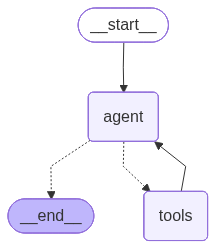

In [4]:
# --- Define Agent State and Nodes ---
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]

def call_model(state: AgentState):
    print("\n📍 Node: AGENT")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        print("📍 Routing → TOOLS")
        return "tools"
    print("📍 Routing → END")
    return END

# --- Build the Graph ---
builder = StateGraph(AgentState)
builder.add_node("agent", call_model)
builder.add_node("tools", tool_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
builder.add_edge("tools", "agent")

app = builder.compile()

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed.")

## 4. Running with Observability
Now we execute the agent with our custom callback handler attached. Every LLM call and tool invocation will be logged.

In [5]:
# Create a fresh handler for this run
handler = ObservabilityHandler()

query = "What is the capital of Japan, and what is its population?"
inputs = {"messages": [HumanMessage(content=query)]}

print(f"Query: {query}")
print("=" * 60)

# Pass the handler via the config dict
config = {"callbacks": [handler]}

for chunk in app.stream(inputs, config=config, stream_mode="values"):
    message = chunk["messages"][-1]
    if hasattr(message, "content") and message.content:
        if isinstance(message, AIMessage) and not message.tool_calls:
            print(f"\n💬 Final Answer: {message.content}")

Query: What is the capital of Japan, and what is its population?

📍 Node: AGENT
  🔵 LLM Call Started (run: 019d755c...)
  🟢 LLM Call Finished (1526ms)
📍 Routing → TOOLS
  🔧 Tool 'lookup_capital' Invoked
  🔧 Tool Finished (0ms)

📍 Node: AGENT
  🔵 LLM Call Started (run: 019d755c...)
  🟢 LLM Call Finished (1453ms)
📍 Routing → TOOLS
  🔧 Tool 'get_population' Invoked
  🔧 Tool Finished (0ms)

📍 Node: AGENT
  🔵 LLM Call Started (run: 019d755c...)
  🟢 LLM Call Finished (1328ms)
📍 Routing → END

💬 Final Answer: The capital of Japan is Tokyo, and its population is approximately 14 million.


## 5. Analyzing the Trace
Let's inspect the structured traces our handler collected.

In [6]:
# Print the full trace log
print("--- Full Trace Log ---")
for i, trace in enumerate(handler.traces):
    print(f"\n[{i+1}] {trace['event'].upper()}")
    for key, value in trace.items():
        if key != "event":
            print(f"     {key}: {value}")

# Print the summary
summary = handler.get_summary()
print("\n" + "=" * 60)
print("OBSERVABILITY SUMMARY")
print(f"  Total LLM Calls:      {summary['total_llm_calls']}")
print(f"  Total Tool Calls:     {summary['total_tool_calls']}")
print(f"  Total Errors:         {summary['total_errors']}")
print(f"  Avg LLM Latency:      {summary['avg_llm_latency_ms']}ms")
print(f"  Avg Tool Latency:     {summary['avg_tool_latency_ms']}ms")
print("=" * 60)

--- Full Trace Log ---

[1] LLM_START
     run_id: 019d755c-96f2-78e2-a5a0-e9cb73c36d1b
     model: models/gemini-2.5-flash
     prompt_preview: Human: What is the capital of Japan, and what is its population?...

[2] LLM_END
     run_id: 019d755c-96f2-78e2-a5a0-e9cb73c36d1b
     latency_ms: 1526
     output_preview: ...

[3] TOOL_START
     run_id: 019d755c-9ce9-7b70-bb11-ce9b134a9dcf
     tool: lookup_capital
     input: {'country': 'Japan'}

[4] TOOL_END
     run_id: 019d755c-9ce9-7b70-bb11-ce9b134a9dcf
     latency_ms: 0
     output_preview: content='Tokyo' name='lookup_capital' tool_call_id='1cc56b07-542b-4533-8432-4109aaed7a86'

[5] LLM_START
     run_id: 019d755c-9ce9-7b70-bb11-ceb568baa9cc
     model: models/gemini-2.5-flash
     prompt_preview: Human: What is the capital of Japan, and what is its population?
AI: {'name': 'lookup_capital', 'arg...

[6] LLM_END
     run_id: 019d755c-9ce9-7b70-bb11-ceb568baa9cc
     latency_ms: 1453
     output_preview: ...

[7] TOOL_START
     r

## 6. LangSmith Integration (Optional)
If you have a LangSmith account, you can enable cloud-based tracing by setting the following environment variables. All traces will then appear in your LangSmith dashboard with full visualization.

```python
# Add these to your .env file:
# LANGCHAIN_TRACING_V2=true
# LANGCHAIN_API_KEY=your_langsmith_api_key
# LANGCHAIN_PROJECT=AgenticAI-LearningPath
```

When enabled, every LangChain/LangGraph execution is automatically traced to LangSmith — no code changes needed beyond setting the env vars.

## Summary

Observability turns a black-box agent into a transparent, debuggable system.

| Approach | Setup | Use Case |
| :--- | :--- | :--- |
| **Custom Callbacks** | No external deps | Local debugging, CI/CD logging, latency profiling |
| **LangSmith** | API key required | Production monitoring, team dashboards, regression detection |

> **Pro-Tip**: Always log the `run_id` for every LLM call. When a user reports a bad response, you can search by `run_id` to replay the exact trace and pinpoint the failure node.

In the next notebook, we'll combine evaluation with observability to assess the **entire trajectory** of a multi-step agent.